#Pengurangan Dimensi Bertahap Pada Dokumen

In [7]:
!pip install Sastrawi pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.2 MB/s eta 0:00:00


In [8]:
import pandas as pd
import re
import pickle
import nltk
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from tqdm import tqdm
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.decomposition import TruncatedSVD
from sklearn import preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [9]:
data = pd.read_csv('hasil_crowling.csv')
data

,Judul,Tanggal,Ringkasan,Kategori
0,"Viral Sopir Truk Nekat Lawan Arah di Jakut, Po...",16 Okt 2024 18:04,Dalam rekaman yang diunggah terlihat sopir tru...,Peristiwa
1,Polisi Pastikan 2 Tersangka Pencabulan di Pant...,16 Okt 2024 18:02,"Kabid Humas Polda Metro Jaya, Kombes Pol Ade A...",Peristiwa
2,Sejumlah Tokoh dan Pakar Siap Sukseskan Pelant...,16 Okt 2024 16:05,Mulusnya transisi pemerintahan dapat menjaga s...,Politik
3,"Kasus Emas Antam, Saksi Sebut Budi Said Lakuka...",16 Okt 2024 16:01,"Mantan Manajer Retail PT Antam, Nuning Septi W...",Peristiwa
4,5 Fakta Terkait Budi Gunawan Diberhentikan dar...,16 Okt 2024 16:00,Dewan Perwakilan Rakyat (DPR) RI telah menerim...,Peristiwa
5,"Pramono: Semua Ketum Parpol Teman Saya, Nanti ...",16 Okt 2024 15:51,"Calon Gubernur Jakarta, Pramono Anung mengaku ...",News
6,DPR Minta Herindra Bisa Netral saat Sudah Resm...,16 Okt 2024 15:41,"Kepada Herindra, Puan menitipkan pesan khusus ...",Peristiwa
7,"Pengamat Nilai Jika SK-ADT Pimpin Sulut, Dukun...",16 Okt 2024 15:25,Pengamat politik dan pemerintahan Sulawesi Uta...,Politik
8,"Cegah Banjir Terulang, Pramono Bakal Bebaskan ...",16 Okt 2024 15:22,Untuk mengatasi banjir di daerah bantaran kali...,News
9,Puan Maharani Masih Irit Bicara soal Pertemuan...,16 Okt 2024 15:03,"Ketua DPP PDI Perjuangan, Puan Maharani belum ...",Politik


In [10]:
df_acak = data.sample(frac=1).reset_index(drop=True)
df_acak

,Judul,Tanggal,Ringkasan,Kategori
0,"Cegah Banjir Terulang, Pramono Bakal Bebaskan ...",16 Okt 2024 15:22,Untuk mengatasi banjir di daerah bantaran kali...,News
1,Budi Gunawan Banjiri Pujian ke Jokowi Usai Dib...,16 Okt 2024 07:15,Budi Gunawan menyebut bahwa Jokowi adalah pemi...,Politik
2,"Jelang Pensiun, Jokowi Bakal Resmikan Bendunga...",16 Okt 2024 10:00,Presiden Joko Widodo atau Jokowi melanjutkan k...,Peristiwa
3,10 Tahun Kerja Bersama: LPDP dan Peran Pendidi...,16 Okt 2024 11:12,"Selama lebih dari satu dekade, LPDP telah mema...",News
4,Jokowi Resmikan Dua Ruas Tol Trans Sumatera Se...,16 Okt 2024 13:45,Presiden Joko Widodo atau Jokowi meresmikan du...,Peristiwa
5,Profil Muhammad Herindra yang Ditunjuk Jokowi ...,16 Okt 2024 09:31,Herindra adalah lulusan Akademi Militer (Akmil...,Peristiwa
6,"Jokowi Kunjungi AMANAH, Puji Karya Anak Muda Aceh",16 Okt 2024 08:04,Jokowi pun memamerkan sejumlah karya yang diha...,Peristiwa
7,"Selama 3 Hari, 768 Pengendara Terjaring Operas...",16 Okt 2024 15:02,"Ade Ary merincikan, 518 pelanggar dari 768 pel...",Peristiwa
8,Polisi Selidiki Laporan Olla Ramlan soal Pence...,16 Okt 2024 14:11,"Polisi menerangkan, akun TikTok dan Instagram ...",Peristiwa
9,Program Asta Cita Prabowo-Gibran Diharap Bisa ...,16 Okt 2024 13:00,PB HMI berharap Prabowo dan Gibran tidak hanya...,Peristiwa


In [11]:
titles = data['Judul']
contents = data['Ringkasan']

data['Ringkasan'] = titles + " " + contents

data['Ringkasan']

,Ringkasan
0,"Viral Sopir Truk Nekat Lawan Arah di Jakut, Po..."
1,Polisi Pastikan 2 Tersangka Pencabulan di Pant...
2,Sejumlah Tokoh dan Pakar Siap Sukseskan Pelant...
3,"Kasus Emas Antam, Saksi Sebut Budi Said Lakuka..."
4,5 Fakta Terkait Budi Gunawan Diberhentikan dar...
5,"Pramono: Semua Ketum Parpol Teman Saya, Nanti ..."
6,DPR Minta Herindra Bisa Netral saat Sudah Resm...
7,"Pengamat Nilai Jika SK-ADT Pimpin Sulut, Dukun..."
8,"Cegah Banjir Terulang, Pramono Bakal Bebaskan ..."
9,Puan Maharani Masih Irit Bicara soal Pertemuan...


In [12]:
X = data['Ringkasan']
y = data['Kategori']

# split data 80% training 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData training (X_train):")
print(X_train.head())

print("\nLabel training (y_train):")
print(y_train.head())

print("\nData testing (X_test):")
print(X_test.head())

print("\nLabel testing (y_test):")
print(y_test.head())


Data training (X_train):
8     Cegah Banjir Terulang, Pramono Bakal Bebaskan ...
26    Pemprov Kalsel Dorong Perangkat Kehumasan Meng...
6     DPR Minta Herindra Bisa Netral saat Sudah Resm...
34    Jokowi Resmikan Bendungan Lausimeme Senilai Rp...
4     5 Fakta Terkait Budi Gunawan Diberhentikan dar...
Name: Ringkasan, dtype: object

Label training (y_train):
8          News
26         News
6     Peristiwa
34    Peristiwa
4     Peristiwa
Name: Kategori, dtype: object

Data testing (X_test):
19    7 Fakta Terkini Terkait Kasus Pelecehan Seksua...
41    Cuaca Besok Kamis 17 Oktober 2024: Langit Jaka...
47    WSBP Dapat Kontrak Proyek Konstruksi Pembangun...
12    Transaksi Digital Dinilai Mampu Tingkatkan Ink...
43    Dasco Bersuara soal Kehadiran Pramono di Kerta...
Name: Ringkasan, dtype: object

Label testing (y_test):
19    Peristiwa
41    Peristiwa
47    Peristiwa
12    Peristiwa
43      Politik
Name: Kategori, dtype: object


In [13]:
def clean_lower(text):
    if isinstance(text, str):
        return text.lower()
    return text

X_train = X_train.apply(clean_lower)
X_test = X_test.apply(clean_lower)

print("Data training setelah diubah menjadi huruf kecil:")
print(X_train.head())

print("\nData testing setelah diubah menjadi huruf kecil:")
print(X_test.head())

Data training setelah diubah menjadi huruf kecil:
8     cegah banjir terulang, pramono bakal bebaskan ...
26    pemprov kalsel dorong perangkat kehumasan meng...
6     dpr minta herindra bisa netral saat sudah resm...
34    jokowi resmikan bendungan lausimeme senilai rp...
4     5 fakta terkait budi gunawan diberhentikan dar...
Name: Ringkasan, dtype: object

Data testing setelah diubah menjadi huruf kecil:
19    7 fakta terkini terkait kasus pelecehan seksua...
41    cuaca besok kamis 17 oktober 2024: langit jaka...
47    wsbp dapat kontrak proyek konstruksi pembangun...
12    transaksi digital dinilai mampu tingkatkan ink...
43    dasco bersuara soal kehadiran pramono di kerta...
Name: Ringkasan, dtype: object


In [14]:
def clean_punct(text):
    if isinstance(text, str):
        clean_patterns = re.compile(r'[0-9]|[/(){}\[\]\|@,;_]|[^a-z ]')
        text = clean_patterns.sub(' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return text

X_train = X_train.apply(clean_punct)
X_test = X_test.apply(clean_punct)

print("Data training setelah dibersihkan:")
print(X_train.head())

print("\nData testing setelah dibersihkan:")
print(X_test.head())

Data training setelah dibersihkan:
8     cegah banjir terulang pramono bakal bebaskan l...
26    pemprov kalsel dorong perangkat kehumasan meng...
6     dpr minta herindra bisa netral saat sudah resm...
34    jokowi resmikan bendungan lausimeme senilai rp...
4     fakta terkait budi gunawan diberhentikan dari ...
Name: Ringkasan, dtype: object

Data testing setelah dibersihkan:
19    fakta terkini terkait kasus pelecehan seksual ...
41    cuaca besok kamis oktober langit jakarta beraw...
47    wsbp dapat kontrak proyek konstruksi pembangun...
12    transaksi digital dinilai mampu tingkatkan ink...
43    dasco bersuara soal kehadiran pramono di kerta...
Name: Ringkasan, dtype: object


In [15]:
def _normalize_whitespace(text):
    if isinstance(text, str):
        corrected = re.sub(r'\s+', ' ', text)
        return corrected.strip()
    return text

X_train = X_train.apply(_normalize_whitespace)
X_test = X_test.apply(_normalize_whitespace)

print("Data training setelah normalisasi spasi:")
print(X_train.head())

print("\nData testing setelah normalisasi spasi:")
print(X_test.head())

Data training setelah normalisasi spasi:
8     cegah banjir terulang pramono bakal bebaskan l...
26    pemprov kalsel dorong perangkat kehumasan meng...
6     dpr minta herindra bisa netral saat sudah resm...
34    jokowi resmikan bendungan lausimeme senilai rp...
4     fakta terkait budi gunawan diberhentikan dari ...
Name: Ringkasan, dtype: object

Data testing setelah normalisasi spasi:
19    fakta terkini terkait kasus pelecehan seksual ...
41    cuaca besok kamis oktober langit jakarta beraw...
47    wsbp dapat kontrak proyek konstruksi pembangun...
12    transaksi digital dinilai mampu tingkatkan ink...
43    dasco bersuara soal kehadiran pramono di kerta...
Name: Ringkasan, dtype: object


In [16]:
def clean_stopwords(text):
    if isinstance(text, str):
        stopword = set(stopwords.words('indonesian'))
        text = ' '.join(word for word in text.split() if word not in stopword)
        return text.strip()
    return text

X_train = X_train.apply(clean_stopwords)
X_test = X_test.apply(clean_stopwords)

print("Data training setelah menghapus stopwords:")
print(X_train.head())

print("\nData testing setelah menghapus stopwords:")
print(X_test.head())

Data training setelah menghapus stopwords:
8     cegah banjir terulang pramono bebaskan lahan b...
26    pemprov kalsel dorong perangkat kehumasan meng...
6     dpr herindra netral resmi kepala bin herindra ...
34    jokowi resmikan bendungan lausimeme senilai rp...
4     fakta terkait budi gunawan diberhentikan jabat...
Name: Ringkasan, dtype: object

Data testing setelah menghapus stopwords:
19    fakta terkini terkait pelecehan seksual panti ...
41    cuaca besok kamis oktober langit jakarta beraw...
47    wsbp kontrak proyek konstruksi pembangunan uni...
12    transaksi digital dinilai tingkatkan inklusi k...
43    dasco bersuara kehadiran pramono kertanegara p...
Name: Ringkasan, dtype: object


In [17]:
def sastrawistemmer(text):
    factory = StemmerFactory()
    st = factory.create_stemmer()
    text = ' '.join(st.stem(word) for word in text.split())
    return text

X_train = X_train.apply(sastrawistemmer)
X_test = X_test.apply(sastrawistemmer)

print("Data training setelah stemming:")
print(X_train.head())

print("\nData testing setelah stemming:")
print(X_test.head())

Data training setelah stemming:
8     cegah banjir ulang pramono bebas lahan bantara...
26    pemprov kalsel dorong perangkat humas kelola i...
6     dpr herindra netral resmi kepala bin herindra ...
34    jokowi resmi bendung lausimeme nila rp triliun...
4     fakta kait budi gunawan henti jabat kepala bin...
Name: Ringkasan, dtype: object

Data testing setelah stemming:
19    fakta kini kait leceh seksual panti asuh yayas...
41    cuaca besok kamis oktober langit jakarta awan ...
47    wsbp kontrak proyek konstruksi bangun unipi pe...
12    transaksi digital nilai tingkat inklusi uang e...
43    dasco suara hadir pramono kertanegara peluang ...
Name: Ringkasan, dtype: object


In [18]:
train_df = pd.DataFrame({'Content': X_train, 'Cattegory': y_train})
test_df = pd.DataFrame({'Content': X_test, 'Cattegory': y_test})

train_df

,Content,Cattegory
8,cegah banjir ulang pramono bebas lahan bantara...,News
26,pemprov kalsel dorong perangkat humas kelola i...,News
6,dpr herindra netral resmi kepala bin herindra ...,Peristiwa
34,jokowi resmi bendung lausimeme nila rp triliun...,Peristiwa
4,fakta kait budi gunawan henti jabat kepala bin...,Peristiwa
37,budi gunawan hadir bekal prabowo subianto hamb...,Peristiwa
24,program asta cita prabowo gibran harap navigas...,Peristiwa
44,calon menteri wakil menteri kepala badan hamba...,Peristiwa
33,kerja lpdp peran didik investasi dekade lpdp m...,News
49,prabowo bekal calon menteri hambalang gibran h...,Peristiwa


In [19]:
test_df

,Content,Cattegory
19,fakta kini kait leceh seksual panti asuh yayas...,Peristiwa
41,cuaca besok kamis oktober langit jakarta awan ...,Peristiwa
47,wsbp kontrak proyek konstruksi bangun unipi pe...,Peristiwa
12,transaksi digital nilai tingkat inklusi uang e...,Peristiwa
43,dasco suara hadir pramono kertanegara peluang ...,Politik
5,pramono tum parpol teman cfd bareng calon gube...,News
17,polisi selidik lapor olla ramlan cemar nama po...,Peristiwa
50,rawan e l carlo tewu juang menang steven kando...,News
3,emas antam saksi budi said laku transaksi curi...,Peristiwa
32,temu konsul jenderal australia pj gubernur jat...,News


In [20]:
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [21]:
tfidf_df = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

tfidf_df

,aceh,acung,ade,adhi,adt,akademi,akademisi,akmil,akses,aktif,...,wapres,warga,warta,wbk,wib,widodo,wilayah,wujud,zebra,zona
0,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.146504,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.131616,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.223387,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.235467,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [22]:
tfidf_df = pd.DataFrame(X_test_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

tfidf_df

,aceh,acung,ade,adhi,adt,akademi,akademisi,akmil,akses,aktif,...,wapres,warga,warta,wbk,wib,widodo,wilayah,wujud,zebra,zona
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
label_encoder = preprocessing.LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [24]:
accuracy_results = []

current_dim = X_train_tfidf.shape[1]

In [25]:
# Looping untuk mengurangi jumlah dimensi sebanyak 20 pada setiap iterasi
while current_dim >= 100:
    print(f"Reducing dimensions to {current_dim}")

    # Inisialisasi dan fit SVD
    svd = TruncatedSVD(n_components=current_dim, random_state=42)

    # Lakukan reduksi dimensi pada data training dan testing
    X_train_lsa = svd.fit_transform(X_train_tfidf)
    X_test_lsa = svd.transform(X_test_tfidf)

    # Melatih model Logistic Regression pada data yang telah direduksi
    lr_model = LogisticRegression()
    lr_model.fit(X_train_lsa, y_train_encoded)

    # Prediksi pada data testing
    y_pred = lr_model.predict(X_test_lsa)

    # Menghitung akurasi dan menambahkannya ke dalam list
    accuracy = accuracy_score(y_test_encoded, y_pred)
    accuracy_results.append({"Dimensions": current_dim, "Accuracy": accuracy})

    # Menampilkan accuracy untuk setiap current_dim
    print(f"Accuracy with {current_dim} components: {accuracy}")

    # Kurangi jumlah dimensi sebanyak 20 untuk iterasi berikutnya
    current_dim -= 20

Reducing dimensions to 459
Accuracy with 459 components: 0.6363636363636364
Reducing dimensions to 439
Accuracy with 439 components: 0.6363636363636364
Reducing dimensions to 419
Accuracy with 419 components: 0.6363636363636364
Reducing dimensions to 399
Accuracy with 399 components: 0.6363636363636364
Reducing dimensions to 379
Accuracy with 379 components: 0.6363636363636364
Reducing dimensions to 359
Accuracy with 359 components: 0.6363636363636364
Reducing dimensions to 339
Accuracy with 339 components: 0.6363636363636364
Reducing dimensions to 319
Accuracy with 319 components: 0.6363636363636364
Reducing dimensions to 299
Accuracy with 299 components: 0.6363636363636364
Reducing dimensions to 279
Accuracy with 279 components: 0.6363636363636364
Reducing dimensions to 259
Accuracy with 259 components: 0.6363636363636364
Reducing dimensions to 239
Accuracy with 239 components: 0.6363636363636364
Reducing dimensions to 219
Accuracy with 219 components: 0.6363636363636364
Reducing dim

In [26]:
accuracy_df = pd.DataFrame(accuracy_results)

accuracy_df

,Dimensions,Accuracy
0,459,0.636364
1,439,0.636364
2,419,0.636364
3,399,0.636364
4,379,0.636364
5,359,0.636364
6,339,0.636364
7,319,0.636364
8,299,0.636364
9,279,0.636364


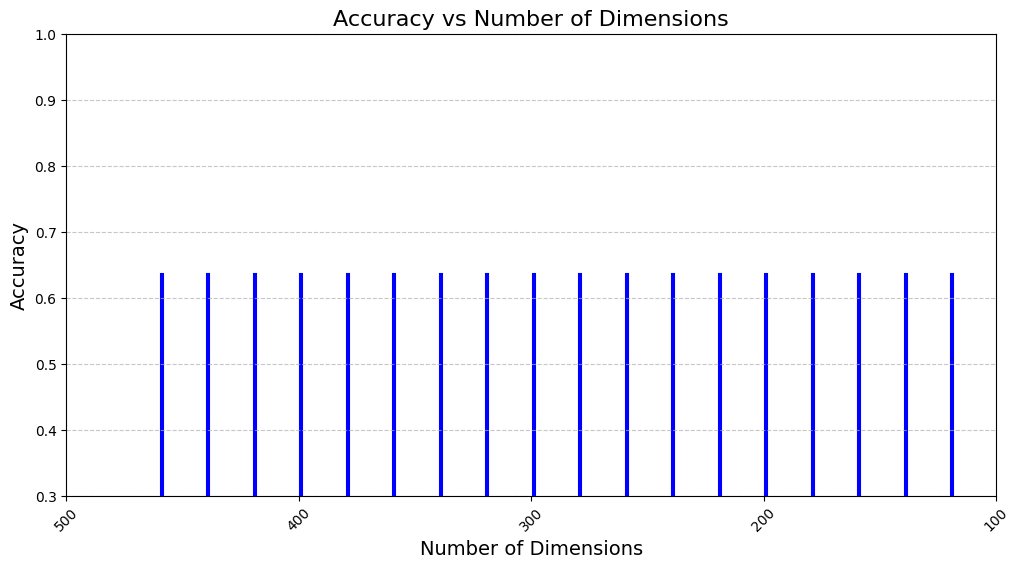

In [27]:
plt.figure(figsize=(12, 6))
plt.bar(accuracy_df["Dimensions"], accuracy_df["Accuracy"], color='skyblue', edgecolor='blue', linewidth=1.5)
plt.title("Accuracy vs Number of Dimensions", fontsize=16)
plt.xlabel("Number of Dimensions", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)

plt.ylim(0.3, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().invert_xaxis()

plt.xticks(range(100, 600, 100), rotation=45)

plt.show()

In [28]:
import pickle
from sklearn.decomposition import TruncatedSVD


# Model Logistic Regression hasil akhir
final_dim = 100  # Anda dapat memilih dimensi akhir sesuai kebutuhan
svd = TruncatedSVD(n_components=final_dim, random_state=42)

# Reduksi dimensi terakhir
X_train_lsa = svd.fit_transform(X_train_tfidf)
X_test_lsa = svd.transform(X_test_tfidf)

# Melatih model Logistic Regression terakhir
lr_model = LogisticRegression()
lr_model.fit(X_train_lsa, y_train_encoded)

# Menyimpan model Logistic Regression, TfidfVectorizer, dan LabelEncoder
with open('logistic_regression_model.pkl', 'wb') as model_file:
    pickle.dump(lr_model, model_file)

with open('tfidf_vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(tfidf_vectorizer, vectorizer_file)

with open('label_encoder.pkl', 'wb') as encoder_file:
    pickle.dump(label_encoder, encoder_file)

print("File pickle berhasil dibuat:")
print("1. logistic_regression_model.pkl")
print("2. tfidf_vectorizer.pkl")
print("3. label_encoder.pkl")



File pickle berhasil dibuat:
1. logistic_regression_model.pkl
2. tfidf_vectorizer.pkl
3. label_encoder.pkl


Link Deployment : https://huggingface.co/spaces/22-065/ppwtugas8